# AI4I 2020 — Failure Prediction Model Training

# AI4I 2020 — Model Training
Training XGBoost models for:
1. Binary failure prediction (with SMOTE + class weights)
2. Failure mode classifiers (TWF, HDF, PWF, OSF)
3. Threshold tuning for operational recall target
4. SHAP explainability validation
All trained models saved to ml/models/

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print("All imports successful")
print(f"XGBoost version: {__import__('xgboost').__version__}")
print(f"SHAP version: {shap.__version__}")

All imports successful
XGBoost version: 3.2.0
SHAP version: 0.51.0


This block is preparing the environment for the machine learning pipeline. 

It imports libraries for:
 data manipulation (Pandas, NumPy), 
 visualization (Matplotlib, Seaborn), 
 model training (XGBoost), 
 handling class imbalance (SMOTE), 
 evaluation (F1, ROC-AUC, Precision-Recall), 
 model explanation (SHAP), and
 file management (OS, Joblib, JSON). 
 
 It also configures display settings, creates output directories, suppresses unnecessary warnings, and verifies that critical packages are installed correctly before moving on to data loading and model training

Overall Purpose
Library Imports — Loads all packages required for data analysis, visualization, feature engineering, model training, evaluation, explainability, and file management.
Environment Configuration — Sets display formats, figure size, and plotting resolution.
Project Setup — Creates folders for saving models and processed outputs.
Verification — Confirms successful installation of critical libraries and displays their versions before starting the machine learning workflow

In [45]:

df = pd.read_csv('../data/raw/ai4i2020.csv')
print(f"Raw data loaded: {df.shape}")

# ── Feature Engineering ────────────────────────────────────
df['temp_diff']         = df['Process temperature [K]'] - df['Air temperature [K]']
df['power']             = df['Torque [Nm]'] * df['Rotational speed [rpm]'] * (2 * np.pi / 60)
df['tool_wear_torque']  = df['Tool wear [min]'] * df['Torque [Nm]']
df['quality_encoded']   = df['Type'].map({'H': 2, 'M': 1, 'L': 0})

#These are the predictor variables (inputs) used by the model.
FEATURE_COLS = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temp_diff',
    'power',
    'tool_wear_torque',
    'quality_encoded'
]

FAILURE_MODE_COLS = ['TWF', 'HDF', 'PWF', 'OSF']  # skip RNF

TARGET_COL = 'Machine failure' #This is the label the model will predict. 0 or 1 indicating whether a machine failure occurred.


X = df[FEATURE_COLS].copy()#Creates a DataFrame containing only the selected features.
y = df[TARGET_COL].copy() #Stores the machine failure labels.
y_modes = df[FAILURE_MODE_COLS].copy()#Stores the individual failure types.

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Failure modes shape  : {y_modes.shape}")
print(f"\nFeature columns:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i}. {col}")
print(f"\nClass distribution: {dict(y.value_counts().sort_index())}") #Counts the number of samples in each target class.

Raw data loaded: (10000, 14)

Feature matrix shape : (10000, 9)
Target shape         : (10000,)
Failure modes shape  : (10000, 4)

Feature columns:
  1. Air temperature [K]
  2. Process temperature [K]
  3. Rotational speed [rpm]
  4. Torque [Nm]
  5. Tool wear [min]
  6. temp_diff
  7. power
  8. tool_wear_torque
  9. quality_encoded

Class distribution: {0: np.int64(9661), 1: np.int64(339)}


The code performs four main tasks:

Loads the AI4I predictive maintenance dataset.


Creates engineered features (temp_diff, power, tool_wear_torque, quality_encoded).


Builds training data:
X → model inputs
y → machine failure target
y_modes → specific failure types


Prints diagnostics such as shapes, feature names, and class distribution to verify the dataset is ready for machine learning.

In [46]:
# ── Stratified Split ───────────────────────────────────────
# stratify=y ensures failure rate is preserved in both splits
X_train, X_test, y_train, y_test, y_modes_train, y_modes_test = train_test_split(
    X, y, y_modes,
    test_size=0.2,
    random_state=42,
    stratify=y
) # x= feature matirx, y=machine failure labels, y_modes= individual failure types
# stratify=y ensures that the proportion of machine failures (the target variable) is preserved in both the training and test sets. This is crucial for imbalanced datasets to ensure that the model learns from a representative sample of both classes.
print("TRAIN/TEST SPLIT (stratified)")

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nFailure rate in training : {y_train.mean()*100:.2f}%")
print(f"Failure rate in test     : {y_test.mean()*100:.2f}%")
print(f"\nFailures in training set : {y_train.sum()}")
print(f"Failures in test set     : {y_test.sum()}")
print("\nFailure rate preserved in both splits — stratification worked")

TRAIN/TEST SPLIT (stratified)
Training set   : 8,000 rows
Test set       : 2,000 rows

Failure rate in training : 3.39%
Failure rate in test     : 3.40%

Failures in training set : 271
Failures in test set     : 68

Failure rate preserved in both splits — stratification worked


In [51]:
#feature scaling (standardization) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # transform only, don't fit becuase the test set must remain completely unseen.


#fit()      -> learn parameters
#transform() -> apply those parameters


# Convert back to DataFrame to keep column names for SHAP
#why?=> fit_transform returns array without column names, but we need them later for SHAP explanations. Converting back to DataFrame allows us to retain the feature names.

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)

print("FEATURE SCALING")
print("=" * 50)
print("Scaler fit on training data only")
print(f"Pre-scaling  — Torque mean : {X_train['torque'].mean():.2f}")
print(f"Post-scaling — Torque mean : {X_train_scaled['torque'].mean():.4f}  (should be ~0)")
print(f"Post-scaling — Torque std  : {X_train_scaled['torque'].std():.4f}   (should be ~1)")

# Save scaler immediately — needed for production inference
joblib.dump(scaler, '../models/scaler_ai4i.joblib')
print("\n✅ Scaler saved → ml/models/scaler_ai4i.joblib")

FEATURE SCALING
Scaler fit on training data only
Pre-scaling  — Torque mean : 40.00
Post-scaling — Torque mean : -0.0000  (should be ~0)
Post-scaling — Torque std  : 1.0001   (should be ~1)

✅ Scaler saved → ml/models/scaler_ai4i.joblib


In [52]:
# ── Fix XGBoost Feature Names ──────────────────────────────
# XGBoost does not allow [ ] or < in feature names
# Rename all columns to safe versions

FEATURE_COLS_SAFE = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear',
    'temp_diff',
    'power',
    'tool_wear_torque',
    'quality_encoded'
]

# Create a mapping from original → safe names
col_rename_map = dict(zip(FEATURE_COLS, FEATURE_COLS_SAFE))

X_train = X_train.rename(columns=col_rename_map)
X_test  = X_test.rename(columns=col_rename_map)

# Update FEATURE_COLS to use safe names from this point forward
FEATURE_COLS = FEATURE_COLS_SAFE

print("Feature columns renamed (XGBoost-safe):")
for safe in FEATURE_COLS:
    print(f"  {safe}")

print("\n✅ No brackets or special characters in column names")

# Save the rename mapping for use in preprocessor.py
import json
with open('../models/feature_name_mapping.json', 'w') as f:
    json.dump(col_rename_map, f, indent=2)
print("✅ feature_name_mapping.json saved")

Feature columns renamed (XGBoost-safe):
  air_temperature
  process_temperature
  rotational_speed
  torque
  tool_wear
  temp_diff
  power
  tool_wear_torque
  quality_encoded

✅ No brackets or special characters in column names
✅ feature_name_mapping.json saved


In [56]:
# ── SMOTE Oversampling (Synthetic Minority Over-sampling Technique) to balance an imbalanced training dataset before training a machine learning model.
# Applied ONLY on training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE OVERSAMPLING")
print("\n\n")
print(f"Before SMOTE:")
print(f"  Training rows     : {len(X_train_scaled):,}")
print(f"  Failures (1)      : {y_train.sum():,}  ({y_train.mean()*100:.2f}%)")
print(f"  No failures (0)   : {(y_train==0).sum():,}")

print(f"\nAfter SMOTE:")
print(f"  Training rows     : {len(X_train_resampled):,}")
unique, counts = np.unique(y_train_resampled, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}           : {cnt:,}  ({cnt/len(y_train_resampled)*100:.2f}%)")

print("\nClasses now balanced for training")
print("Test set remains UNTOUCHED — real-world distribution preserved")

SMOTE OVERSAMPLING



Before SMOTE:
  Training rows     : 8,000
  Failures (1)      : 271  (3.39%)
  No failures (0)   : 7,729

After SMOTE:
  Training rows     : 15,458
  Class 0           : 7,729  (50.00%)
  Class 1           : 7,729  (50.00%)

Classes now balanced for training
Test set remains UNTOUCHED — real-world distribution preserved


SMOTE generates synthetic examples of the minority class instead of simply duplicating existing records.


random_state=42
Ensures reproducible results.
Running the code again produces the same synthetic samples.


k_neighbors=5
For each minority-class sample, SMOTE looks at its 5 nearest minority-class neighbors.
New synthetic points are created between the sample and its neighbors.

======================================================================================================

In [57]:
# ── XGBoost Binary Classifier ─────────────────────────────
print("TRAINING FAILURE PREDICTION MODEL")
print("=" * 50)

# Calculate class weight ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight = {neg_count}/{pos_count} = {scale_pos_weight:.1f}")

failure_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

# Train with early stopping
# eval_set monitors performance on test set during training
failure_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

print(f"\nBest iteration    : {failure_model.best_iteration}")
print(f"Best PR-AUC score : {failure_model.best_score:.4f}")


TRAINING FAILURE PREDICTION MODEL
scale_pos_weight = 7729/271 = 28.5

Best iteration    : 51
Best PR-AUC score : 0.8463


This code trains an XGBoost binary classification model to predict failures (1) vs. non-failures (0).



scale_pos_weight tells XGBoost:


"Mistakes on the positive class (failures) are more costly."

This increases the importance of minority-class examples.

The code builds and trains an XGBoost failure-prediction model on SMOTE-balanced data, handles class imbalance with weighting, uses PR-AUC for evaluation, and employs early stopping to prevent overfitting.

============================================================================================================================

MODEL EVALUATION — Default Threshold (0.5)
              precision    recall  f1-score   support

  No Failure       1.00      0.71      0.83      1932
     Failure       0.11      1.00      0.20        68

    accuracy                           0.72      2000
   macro avg       0.55      0.85      0.51      2000
weighted avg       0.97      0.72      0.81      2000

ROC-AUC  : 0.9806
PR-AUC   : 0.8467
F1 Score : 0.1951


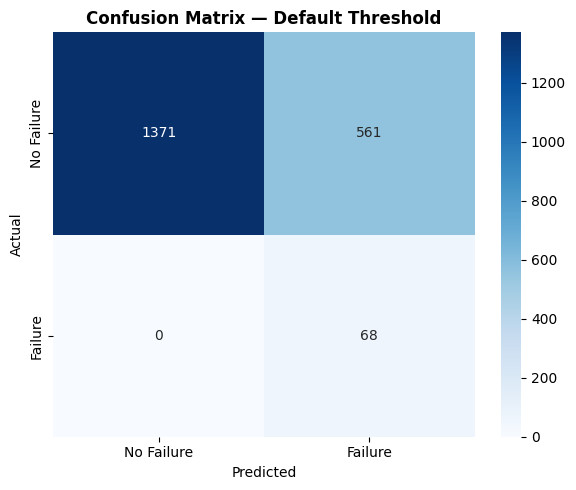


TN (correct no-failure) : 1371
FP (false alarm): 561
FN (missed failure): 0
TP (caught failure)  : 68


In [ ]:
# Evaluation at Default Threshold (0.5)
print("MODEL EVALUATION — Default Threshold (0.5)")
print("=" * 50)

y_pred_proba = failure_model.predict_proba(X_test_scaled)[:, 1] #Produces the probability that each test sample belongs to the Failure (1) class.
y_pred_default = (y_pred_proba >= 0.5).astype(int)#Convert probabilities to class predictions

print(classification_report(y_test, y_pred_default,
                             target_names=['No Failure', 'Failure']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)
f1      = f1_score(y_test, y_pred_default)

print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_default)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
ax.set_title('Confusion Matrix — Default Threshold', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/07_confusion_matrix_default.png', dpi=100, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTN (correct no-failure) : {tn}")
print(f"FP (false alarm): {fp}")
print(f"FN (missed failure): {fn}")
print(f"TP (caught failure)  : {tp}")

The code evaluates how well the model detects failures on the unseen test dataset, reports key performance metrics (ROC-AUC, PR-AUC, F1-score), and visualizes prediction results through a confusion matrix to understand false alarms and missed failures.

==============================================================================================================================================


THRESHOLD TUNING
Goal: recall > 0.85 while precision > 0.40

Best threshold : 0.89
  Recall       : 0.9118
  Precision    : 0.3010
  F1           : 0.4526


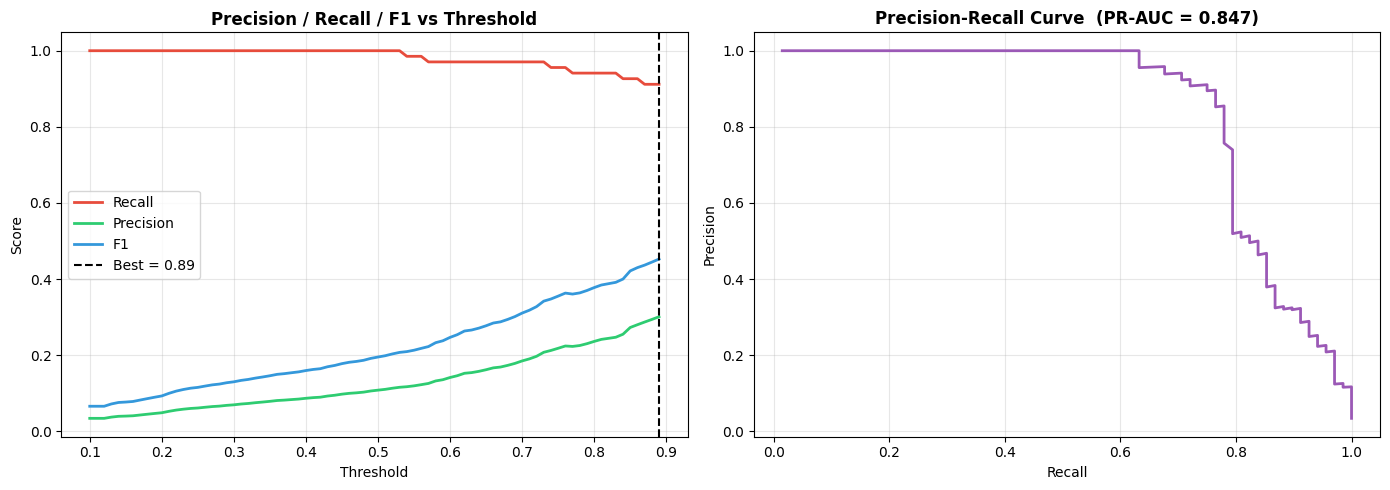


EVALUATION AT BEST THRESHOLD (0.89)
              precision    recall  f1-score   support

  No Failure       1.00      0.93      0.96      1932
     Failure       0.30      0.91      0.45        68

    accuracy                           0.93      2000
   macro avg       0.65      0.92      0.71      2000
weighted avg       0.97      0.93      0.94      2000



In [ ]:
#Threshold Tuning 
# Goal: maximize recall (catch more real failures)
# while keeping precision > 0.4 (avoid too many false alarms)
print("THRESHOLD TUNING")
print("=" * 50)
print("Goal: recall > 0.85 while precision > 0.40")
print()

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)#Generate Precision-Recall Data

# Find best threshold
results = []
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_pred_proba >= thresh).astype(int)
    if y_pred_t.sum() == 0:
        continue
    p = f1_score(y_test, y_pred_t, zero_division=0)
    r = (y_pred_t[y_test == 1]).mean()
    prec = (y_test[y_pred_t == 1]).mean() if y_pred_t.sum() > 0 else 0
    results.append({'threshold': thresh, 'f1': p, 'recall': r, 'precision': prec})

results_df = pd.DataFrame(results)

# Best threshold: highest F1 where recall > 0.80
valid = results_df[results_df['recall'] >= 0.80]
if len(valid) > 0:
    best = valid.loc[valid['f1'].idxmax()]
else:
    best = results_df.loc[results_df['f1'].idxmax()]

BEST_THRESHOLD = round(float(best['threshold']), 2)

print(f"Best threshold : {BEST_THRESHOLD}")
print(f"  Recall       : {best['recall']:.4f}")
print(f"  Precision    : {best['precision']:.4f}")
print(f"  F1           : {best['f1']:.4f}")

# Visualize threshold curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['recall'],
             label='Recall', color='#e74c3c', linewidth=2)
axes[0].plot(results_df['threshold'], results_df['precision'],
             label='Precision', color='#2ecc71', linewidth=2)
axes[0].plot(results_df['threshold'], results_df['f1'],
             label='F1', color='#3498db', linewidth=2)
axes[0].axvline(x=BEST_THRESHOLD, color='black', linestyle='--',
                linewidth=1.5, label=f'Best = {BEST_THRESHOLD}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR Curve
axes[1].plot(recalls[:-1], precisions[:-1], color='#9b59b6', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve  (PR-AUC = {pr_auc:.3f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/08_threshold_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

# Evaluate at best threshold
y_pred_best = (y_pred_proba >= BEST_THRESHOLD).astype(int)
print(f"\nEVALUATION AT BEST THRESHOLD ({BEST_THRESHOLD})")
print("=" * 50)
print(classification_report(y_test, y_pred_best,
                             target_names=['No Failure', 'Failure']))

This code finds the best probability threshold for converting model probabilities into failure/no-failure predictions. Instead of using the default threshold of 0.5, it searches for a threshold that improves failure detection (recall) while maintaining reasonable precision.

=============================================================================================================================================

In [61]:
# ── Stratified K-Fold Cross Validation 
print("5-FOLD STRATIFIED CROSS VALIDATION")
print("=" * 50)
print("Validates model isn't overfit to one train/test split")
print()

cv_model = XGBClassifier(
    n_estimators=failure_model.best_iteration,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1 = cross_val_score(cv_model, X_train_scaled, y_train,
                              cv=skf, scoring='f1')
cv_roc= cross_val_score(cv_model, X_train_scaled, y_train,
                              cv=skf, scoring='roc_auc')
cv_pr = cross_val_score(cv_model, X_train_scaled, y_train,
                              cv=skf, scoring='average_precision')

print(f"F1 Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"ROC-AUC   : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print(f"PR-AUC    : {cv_pr.mean():.4f} ± {cv_pr.std():.4f}")
print()

if cv_f1.std() < 0.05:
    print("Low variance across folds — model is stable")
else:
    print("High variance — model may be overfitting")

5-FOLD STRATIFIED CROSS VALIDATION
Validates model isn't overfit to one train/test split

F1 Score  : 0.5805 ± 0.0232
ROC-AUC   : 0.9828 ± 0.0116
PR-AUC    : 0.8822 ± 0.0254

Low variance across folds — model is stable


In [63]:
# ── Failure Mode Classifiers (Multi-Label) ────────────────
print("TRAINING FAILURE MODE CLASSIFIERS")
print("=" * 50)
print("One XGBoost per failure mode: TWF, HDF, PWF, OSF")
print()

failure_mode_models = {}
failure_mode_thresholds = {}

for mode in FAILURE_MODE_COLS:
    y_mode_train = y_modes_train[mode]
    y_mode_test  = y_modes_test[mode]

    pos = y_mode_train.sum()
    neg = (y_mode_train == 0).sum()
    spw = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=42,
        verbosity=0
    )

    model.fit(X_train_scaled, y_mode_train)

    # Evaluate
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    f1  = f1_score(y_mode_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_mode_test, y_proba) if y_mode_test.sum() > 0 else 0

    failure_mode_models[mode] = model
    failure_mode_thresholds[mode] = 0.5

    print(f"  {mode}: F1={f1:.4f}  ROC-AUC={auc:.4f}  "
          f"(pos={pos}, scale_pos_weight={spw:.1f})")

    # Save model
    joblib.dump(model, f'../models/failure_mode_{mode}.joblib')
    print(f"       Saved → ml/models/failure_mode_{mode}.joblib")

print("\nAll failure mode classifiers trained and saved")

TRAINING FAILURE MODE CLASSIFIERS
One XGBoost per failure mode: TWF, HDF, PWF, OSF

  TWF: F1=0.1154  ROC-AUC=0.9488  (pos=36, scale_pos_weight=221.2)
       Saved → ml/models/failure_mode_TWF.joblib
  HDF: F1=0.9492  ROC-AUC=0.9998  (pos=86, scale_pos_weight=92.0)
       Saved → ml/models/failure_mode_HDF.joblib
  PWF: F1=0.9286  ROC-AUC=0.9997  (pos=82, scale_pos_weight=96.6)
       Saved → ml/models/failure_mode_PWF.joblib
  OSF: F1=0.9697  ROC-AUC=1.0000  (pos=82, scale_pos_weight=96.6)
       Saved → ml/models/failure_mode_OSF.joblib

All failure mode classifiers trained and saved


SHAP EXPLAINABILITY ANALYSIS
SHAP values shape : (2000, 9)
Expected value    : 3.3551  (baseline prediction)


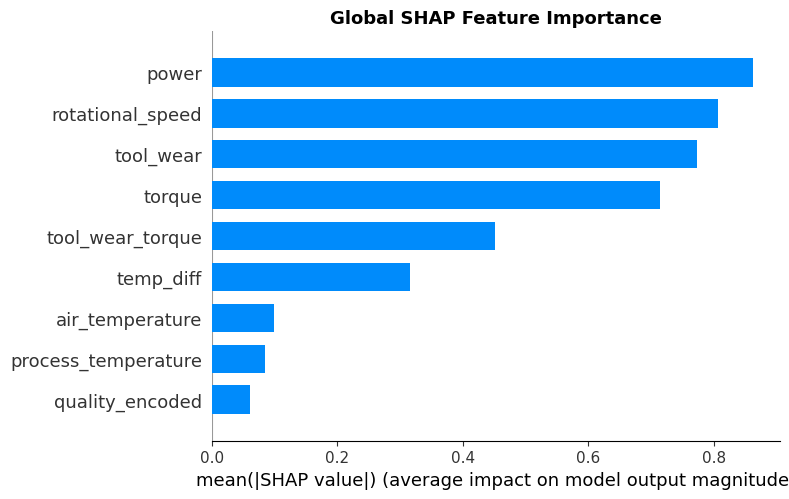

Global importance plot saved.


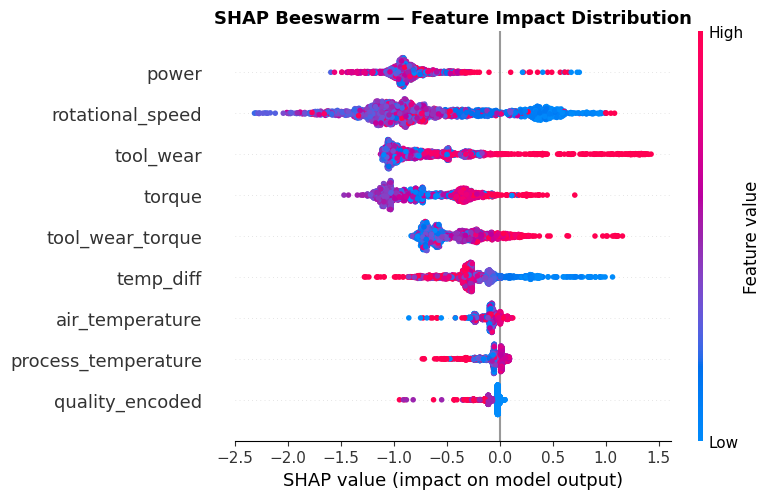

Beeswarm plot saved.


In [64]:
# ── SHAP Explainability ────────────────────────────────────
print("SHAP EXPLAINABILITY ANALYSIS")
print("=" * 50)

explainer = shap.TreeExplainer(failure_model)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value    : {explainer.expected_value:.4f}  (baseline prediction)")

# ── Global Feature Importance ──────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=FEATURE_COLS,
    plot_type="bar",
    show=False
)
plt.title("Global SHAP Feature Importance", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/09_shap_global_importance.png',
            dpi=100, bbox_inches='tight')
plt.show()
print("Global importance plot saved.")

# ── SHAP Beeswarm Plot ─────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact Distribution", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/10_shap_beeswarm.png',
            dpi=100, bbox_inches='tight')
plt.show()
print("Beeswarm plot saved.")

In [65]:
# ── SHAP Single Prediction Explanation ────────────────────
# Demonstrate what FleetMind will show per machine
print("SHAP — SINGLE PREDICTION EXPLANATION")
print("=" * 50)
print("Demonstrating what FleetMind shows per machine\n")

# Find a high-risk sample from test set
high_risk_indices = np.where(y_pred_proba >= 0.70)[0]

if len(high_risk_indices) > 0:
    idx = high_risk_indices[0]
    sample = X_test_scaled.iloc[[idx]]
    sample_shap = shap_values[idx]
    sample_proba = y_pred_proba[idx]
    actual_label = y_test.iloc[idx]

    print(f"Sample index      : {idx}")
    print(f"Failure prob      : {sample_proba:.4f}  ({sample_proba*100:.1f}%)")
    print(f"Actual label      : {'FAILURE' if actual_label == 1 else 'NO FAILURE'}")
    print(f"Baseline (avg)    : {explainer.expected_value:.4f}")
    print()
    print("Feature Contributions:")
    print("-" * 55)

    contributions = list(zip(FEATURE_COLS, sample_shap))
    contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)

    for feat, shap_val in contributions_sorted:
        direction = "↑ RISK" if shap_val > 0 else "↓ REDUCES RISK"
        bar = '█' * int(abs(shap_val) * 60)
        print(f"  {feat:<35} {shap_val:+.4f}  {direction}")

    print()
    print("This is exactly what FleetMind's explainability panel displays.")
else:
    print("No high-risk samples in test set at threshold 0.70")
    print("Try a lower threshold or different random_state")

SHAP — SINGLE PREDICTION EXPLANATION
Demonstrating what FleetMind shows per machine

Sample index      : 0
Failure prob      : 0.9565  (95.6%)
Actual label      : NO FAILURE
Baseline (avg)    : 3.3551

Feature Contributions:
-------------------------------------------------------
  rotational_speed                    +0.3811  ↑ RISK
  torque                              +0.2682  ↑ RISK
  power                               -0.2625  ↓ REDUCES RISK
  temp_diff                           -0.1968  ↓ REDUCES RISK
  tool_wear                           -0.1441  ↓ REDUCES RISK
  air_temperature                     -0.1285  ↓ REDUCES RISK
  tool_wear_torque                    -0.1158  ↓ REDUCES RISK
  process_temperature                 -0.0612  ↓ REDUCES RISK
  quality_encoded                     -0.0059  ↓ REDUCES RISK

This is exactly what FleetMind's explainability panel displays.


In [67]:
# ── Save All Models and Metadata ──────────────────────────
print("SAVING ALL MODELS AND METADATA")
print("=" * 50)

# 1. Failure prediction model
joblib.dump(failure_model, '../models/failure_classifier.joblib')
print(" failure_classifier.joblib")

# 2. Scaler (already saved in Cell 5, confirming)
print(" scaler_ai4i.joblib (saved earlier)")

# 3. Threshold configuration
threshold_config = {
    "failure_prediction": {
        "threshold": BEST_THRESHOLD,
        "description": "Optimal threshold balancing recall and precision",
        "target_recall": 0.80
    },
    "failure_modes": {
        mode: failure_mode_thresholds[mode]
        for mode in FAILURE_MODE_COLS
    },
    "feature_columns": FEATURE_COLS,
    "failure_mode_columns": FAILURE_MODE_COLS
}

with open('../models/threshold_config.json', 'w') as f:
    json.dump(threshold_config, f, indent=2)
print(" threshold_config.json")

# 4. SHAP metadata
shap_metadata = {
    "expected_value": float(explainer.expected_value),
    "feature_columns": FEATURE_COLS
}
with open('../models/shap_metadata.json', 'w') as f:
    json.dump(shap_metadata, f, indent=2)
print(" shap_metadata.json")

# 5. Verify all files exist
print("\nFiles in ml/models/:")
for f in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f:<45} {size/1024:.1f} KB")

SAVING ALL MODELS AND METADATA
 failure_classifier.joblib
 scaler_ai4i.joblib (saved earlier)
 threshold_config.json
 shap_metadata.json

Files in ml/models/:
  .gitkeep                                      0.0 KB
  failure_classifier.joblib                     116.7 KB
  failure_mode_HDF.joblib                       201.4 KB
  failure_mode_OSF.joblib                       205.5 KB
  failure_mode_PWF.joblib                       217.8 KB
  failure_mode_TWF.joblib                       241.2 KB
  feature_name_mapping.json                     0.3 KB
  scaler_ai4i.joblib                            1.1 KB
  shap_metadata.json                            0.3 KB
  threshold_config.json                         0.5 KB


In [68]:
#  Training Summary 
print("\n")
print("TRAINING COMPLETE — SUMMARY")
print("\n")

y_pred_final = (y_pred_proba >= BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print(f"""
FAILURE PREDICTION MODEL:
  Algorithm         : XGBoost Classifier
  Best iteration    : {failure_model.best_iteration}
  Optimal threshold : {BEST_THRESHOLD}

  Test Set Results:
  ROC-AUC           : {roc_auc_score(y_test, y_pred_proba):.4f}
  PR-AUC            : {average_precision_score(y_test, y_pred_proba):.4f}
  F1 Score          : {f1_score(y_test, y_pred_final):.4f}
  Recall (failures) : {tp/(tp+fn):.4f}  ← {tp} of {tp+fn} failures caught
  False Alarms      : {fp}

FAILURE MODE CLASSIFIERS:
  TWF model :  saved
  HDF model : saved
  PWF model :  saved
  OSF model :  saved

EXPLAINABILITY:
  TreeSHAP initialized : 
  Expected value       : {explainer.expected_value:.4f}

SAVED ARTIFACTS:
  failure_classifier.joblib
  failure_mode_TWF/HDF/PWF/OSF.joblib
  scaler_ai4i.joblib
  threshold_config.json
  shap_metadata.json

NEXT STEP:
  → ml/predictor.py  : wrap these models into production functions
  → ml/explainer.py  : wrap SHAP into production class
""")



TRAINING COMPLETE — SUMMARY



FAILURE PREDICTION MODEL:
  Algorithm         : XGBoost Classifier
  Best iteration    : 51
  Optimal threshold : 0.89

  Test Set Results:
  ROC-AUC           : 0.9806
  PR-AUC            : 0.8467
  F1 Score          : 0.4526
  Recall (failures) : 0.9118  ← 62 of 68 failures caught
  False Alarms      : 144

FAILURE MODE CLASSIFIERS:
  TWF model :  saved
  HDF model : saved
  PWF model :  saved
  OSF model :  saved

EXPLAINABILITY:
  TreeSHAP initialized : 
  Expected value       : 3.3551

SAVED ARTIFACTS:
  failure_classifier.joblib
  failure_mode_TWF/HDF/PWF/OSF.joblib
  scaler_ai4i.joblib
  threshold_config.json
  shap_metadata.json

NEXT STEP:
  → ml/predictor.py  : wrap these models into production functions
  → ml/explainer.py  : wrap SHAP into production class

